# Librerías

In [2]:
pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/1b/7c/66d34dc231a309cc3a7f3eeb848319be3b616fd2918db302aaef727eff4a/scikit_learn-1.3.1-cp39-cp39-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.1.1 from https://files.pythonhosted.org/packages/10/40/d551139c85db202f1f384ba8bcf96aca2f329440a844f924c8a0040b6d02/joblib-1.3.2-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=2.0.0 from https://files.pythonhosted.org/packages/81/12/fd4dea011af9d69e1cad05c75f3f7202cdcbeac9b712eea58ca779a72865/threadpoolctl-3.2.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB 8.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/9.3 MB 6.8 MB/s eta 0:00:02
   --- ------------------------------------ 0.9/9.3 MB 7.0 MB/s eta 0:00:02
   ---- ----------------------------------- 1.1/9.3 MB 6.6 MB/s e

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from PIL import Image

# Imagen

Se carga la imagen que se va a utilizar

In [7]:
image_path = 'logo_universidad_nacional.png'
image = Image.open(image_path)

# Imagen original

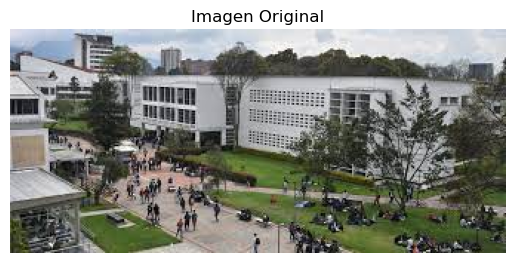

In [8]:
plt.imshow(image)
plt.axis('off')
plt.title('Imagen Original')
plt.show()

# Conversión de la imagen

Convierte la imagen a formato RGB (elimina el canal alfa)

In [9]:
image_rgb = image.convert('RGB')

#  Converión a Matriz

Se convierte la imagen en una matriz numpy

In [10]:
image_array_alpha = np.array(image)
image_array = np.array(image_rgb)

In [11]:
print(f'Las dimensiones con el canal alfa son: {image_array_alpha.shape}')
print(f'Las dimensiones quitando el canal alfa son: {image_array.shape}')

Las dimensiones con el canal alfa son: (151, 335, 3)
Las dimensiones quitando el canal alfa son: (151, 335, 3)


# Imagen por canales

Se muestra cada uno de los canales de la imagen RGB.

[[223 223 222 ... 198 197 197]
 [224 223 223 ... 196 195 194]
 [223 223 222 ... 206 205 205]
 ...
 [ 66  31  52 ...  60  62  63]
 [ 74  31  54 ...  53  48  44]
 [ 72  35  58 ...  62  57  52]]


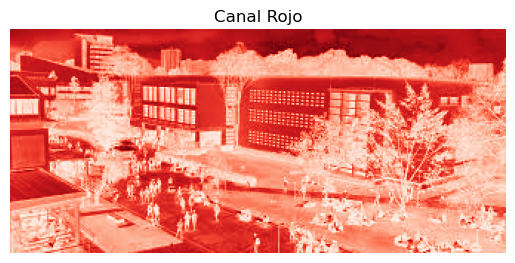

In [12]:
red = image_array[:, :, 0]

print(red)
plt.imshow(red, cmap='Reds')
plt.axis('off')
plt.title('Canal Rojo')
plt.show()

[[221 221 220 ... 206 205 205]
 [222 221 221 ... 204 203 202]
 [223 223 221 ... 212 211 211]
 ...
 [ 70  35  55 ...  73  75  75]
 [ 77  34  57 ...  66  61  56]
 [ 74  37  60 ...  75  70  64]]


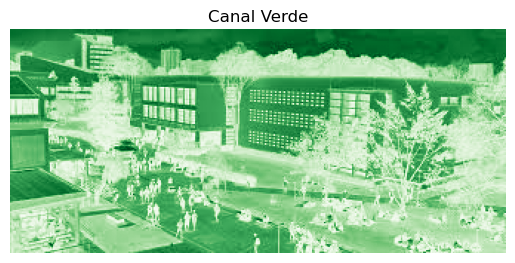

In [13]:
green = image_array[:, :, 1]

print(green)

plt.imshow(green, cmap='Greens')
plt.axis('off')
plt.title('Canal Verde')
plt.show()

[[232 232 233 ... 219 218 218]
 [233 232 234 ... 217 216 215]
 [235 235 235 ... 224 223 223]
 ...
 [ 47  12  34 ...  45  49  53]
 [ 58  15  40 ...  38  35  34]
 [ 60  23  46 ...  47  44  42]]


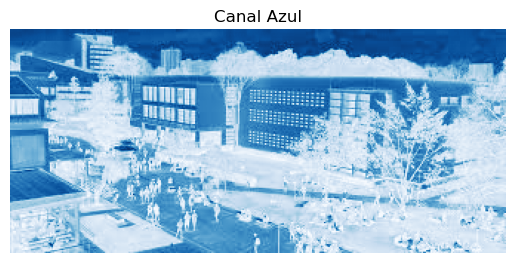

In [14]:
blue = image_array[:, :, 2]

print(blue)

plt.imshow(blue, cmap='Blues')
plt.axis('off')
plt.title('Canal Azul')
plt.show()

# Normalización y organización

Aplana la matriz y normaliza los valores de los píxeles, teniendo en cuenta que cada uno de los canales RGB contienen numeros enteros que varían entre 0 y 255.

In [15]:
dim1 = image_array.shape[0]
dim2 = image_array.shape[1]
dim3 = image_array.shape[2]
print(f'Dim1: {dim1}\nDim2: {dim2}\nDim3: {dim3}')

Dim1: 151
Dim2: 335
Dim3: 3


In [16]:
pixels = np.reshape(image_array, (dim1, dim2*dim3))/255.0

# PCA

Se crea una instancia con el número de componentes que se desean.

In [18]:
pca_5 = PCA(n_components=5)
pca_25 = PCA(n_components=25)

In [19]:
n_componentes = int(input('Indique el número de componentes que desea:'))
pca_n = PCA(n_components=n_componentes) 

Indique el número de componentes que desea:15


# Ajuste

Se realiza el ajuste a los datos de los pixeles normalizados

In [20]:
pca_5.fit(pixels)
pixels_pca_5 = pca_5.transform(pixels)

pca_25.fit(pixels)
pixels_pca_25 = pca_25.transform(pixels)

pca_n.fit(pixels)
pixels_pca_n = pca_n.transform(pixels)

In [21]:
print('Con 5 componentes los resultados son:')
print('Las dimensiones quedan cómo:', pixels_pca_5.shape, end='\n\n')

print('La varianza explicada por cada una de las componentes principales es:', pca_5.explained_variance_ratio_, end='\n\n')

print('La varianza total explicada por las componentes es:', np.sum(pca_5.explained_variance_ratio_), end='\n\n')

Con 5 componentes los resultados son:
Las dimensiones quedan cómo: (151, 5)

La varianza explicada por cada una de las componentes principales es: [0.40626408 0.10409618 0.07265838 0.05499603 0.030578  ]

La varianza total explicada por las componentes es: 0.6685926727114478



In [22]:
print('Con 25 componentes los resultados son:')
print('Las dimensiones quedan cómo:', pixels_pca_25.shape, end='\n\n')

print('La varianza explicada por cada una de las componentes principales es:', pca_25.explained_variance_ratio_, end='\n\n')

print('La varianza total explicada por las componentes es:', np.sum(pca_25.explained_variance_ratio_), end='\n\n')

Con 25 componentes los resultados son:
Las dimensiones quedan cómo: (151, 25)

La varianza explicada por cada una de las componentes principales es: [0.40626408 0.10409618 0.07265838 0.05499603 0.030578   0.02563275
 0.02399732 0.02046485 0.01866292 0.01372881 0.01281154 0.01151434
 0.01065815 0.00998222 0.00971035 0.00805373 0.00763971 0.00685421
 0.00627267 0.00552047 0.00539387 0.00521304 0.00480809 0.00461543
 0.00424369]

La varianza total explicada por las componentes es: 0.8843708281014984



In [23]:
print(f'Con {n_componentes} componentes los resultados son:')
print('Las dimensiones quedan cómo:', pixels_pca_n.shape, end='\n\n')

print('La varianza explicada por cada una de las componentes principales es:', pca_n.explained_variance_ratio_, end='\n\n')

print('La varianza total explicada por las componentes es:', np.sum(pca_n.explained_variance_ratio_), end='\n\n')

Con 15 componentes los resultados son:
Las dimensiones quedan cómo: (151, 15)

La varianza explicada por cada una de las componentes principales es: [0.40626408 0.10409618 0.07265838 0.05499603 0.030578   0.02563275
 0.02399732 0.02046485 0.01866292 0.01372883 0.01281155 0.01151439
 0.01065817 0.00998232 0.00971039]

La varianza total explicada por las componentes es: 0.8257561660323984



# Visualización de resultados

In [24]:
reconstructed_pixels_5 = pca_5.inverse_transform(pixels_pca_5)

# Se reescalan los datos
reconstructed_pixels_5 = reconstructed_pixels_5 * 255.0

# Redimensiona la matriz reconstruida a la forma de la imagen original
reconstructed_image_array_5 = reconstructed_pixels_5.reshape(image_array.shape)


In [25]:
reconstructed_pixels_25 = pca_25.inverse_transform(pixels_pca_25)

# Se reescalan los datos
reconstructed_pixels_25 = reconstructed_pixels_25 * 255.0

# Redimensiona la matriz reconstruida a la forma de la imagen original
reconstructed_image_array_25 = reconstructed_pixels_25.reshape(image_array.shape)


In [26]:
reconstructed_pixels_n = pca_n.inverse_transform(pixels_pca_n)

# Se reescalan los datos
reconstructed_pixels_n = reconstructed_pixels_n * 255.0

# Redimensiona la matriz reconstruida a la forma de la imagen original
reconstructed_image_array_n = reconstructed_pixels_n.reshape(image_array.shape)


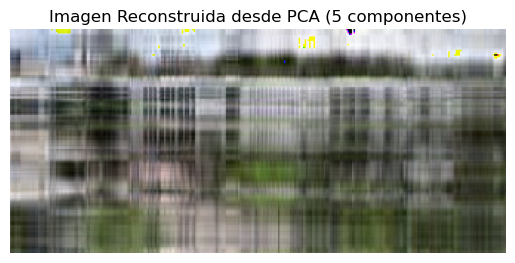

In [27]:
reconstructed_image_5 = Image.fromarray(reconstructed_image_array_5.astype('uint8'))
plt.imshow(reconstructed_image_5)
plt.axis('off')
plt.title('Imagen Reconstruida desde PCA (5 componentes)')
plt.show()

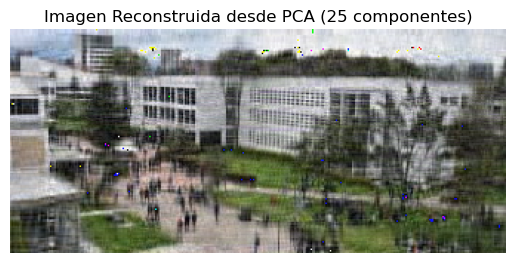

In [28]:
reconstructed_image_25 = Image.fromarray(reconstructed_image_array_25.astype('uint8'))
plt.imshow(reconstructed_image_25)
plt.axis('off')
plt.title('Imagen Reconstruida desde PCA (25 componentes)')
plt.show()

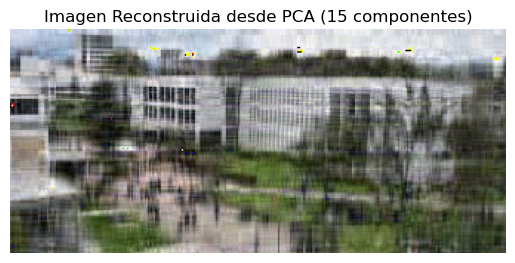

In [29]:
reconstructed_image_n = Image.fromarray(reconstructed_image_array_n.astype('uint8'))
plt.imshow(reconstructed_image_n)
plt.axis('off')
plt.title(f'Imagen Reconstruida desde PCA ({n_componentes} componentes)')
plt.show()